<a href="https://colab.research.google.com/github/kaydominium/csui-archive/blob/main/CSGE603130/TP2_A3_K_A2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUGAS KELOMPOK 2 - Life Expectancy**

Kelompok **K-A2AC**
1. Arya Putra Parikesit (2406406300)
2. Cathlin Abigail (2406418774)
3. Khawarizmi Aydin (2406396584)
4. Msy Aulya Salsabila Putri (2406353364)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns', None)

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

# clean the spacing
df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

df_train.drop_duplicates()

df_train['Status'] = df_train['Status'].map({'Developing': 1, 'Developed': 0})

display(df_train.head())
display(df_train.info())

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Hepatitis B,Polio,Diphtheria,Population,HIV/AIDS
0,1967,0,75.958705,30.409030,7,16.891705,100.000000,77790,7.022069,10,20.000000,79835.055962,0.633306,0.530616,0.747018,12.774990,0.0,76.0,92.0,64121.0,0.100000
1,1990,1,42.915277,101.499444,18,8.230195,0.000000,2106,5.000000,28,3.613611,10.000000,11.396052,11.049630,0.300171,9.982904,100.0,53.0,35.0,2364183.0,4.976989
2,1974,1,49.322096,209.702245,81,0.010000,0.000000,0,30.193667,108,6.405683,1766.947595,4.906007,4.736414,0.440699,7.317002,0.0,100.0,100.0,821554.0,0.100000
3,1970,1,30.000000,452.548059,168,5.347899,0.000000,29763,10.879758,298,0.000000,1766.947595,11.346782,11.946921,0.677000,12.300000,0.0,83.0,63.0,738541.0,0.100000
4,2010,1,61.800000,261.000000,162,1.340000,67.733744,4235,15.600000,243,6.860000,341.399920,11.000000,1.700000,0.401000,8.100000,62.0,69.0,61.0,877267.0,1.700000


<class 'pandas.DataFrame'>
RangeIndex: 10070 entries, 0 to 10069
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             10070 non-null  int64  
 1   Status                           10070 non-null  int64  
 2   Life expectancy                  10062 non-null  float64
 3   Adult Mortality                  10062 non-null  float64
 4   infant deaths                    10070 non-null  int64  
 5   Alcohol                          9920 non-null   float64
 6   percentage expenditure           10070 non-null  float64
 7   Measles                          10070 non-null  int64  
 8   BMI                              10047 non-null  float64
 9   under-five deaths                10070 non-null  int64  
 10  Total expenditure                9894 non-null   float64
 11  GDP                              9707 non-null   float64
 12  thinness  1-19 years         

None

## Data Preprocessing

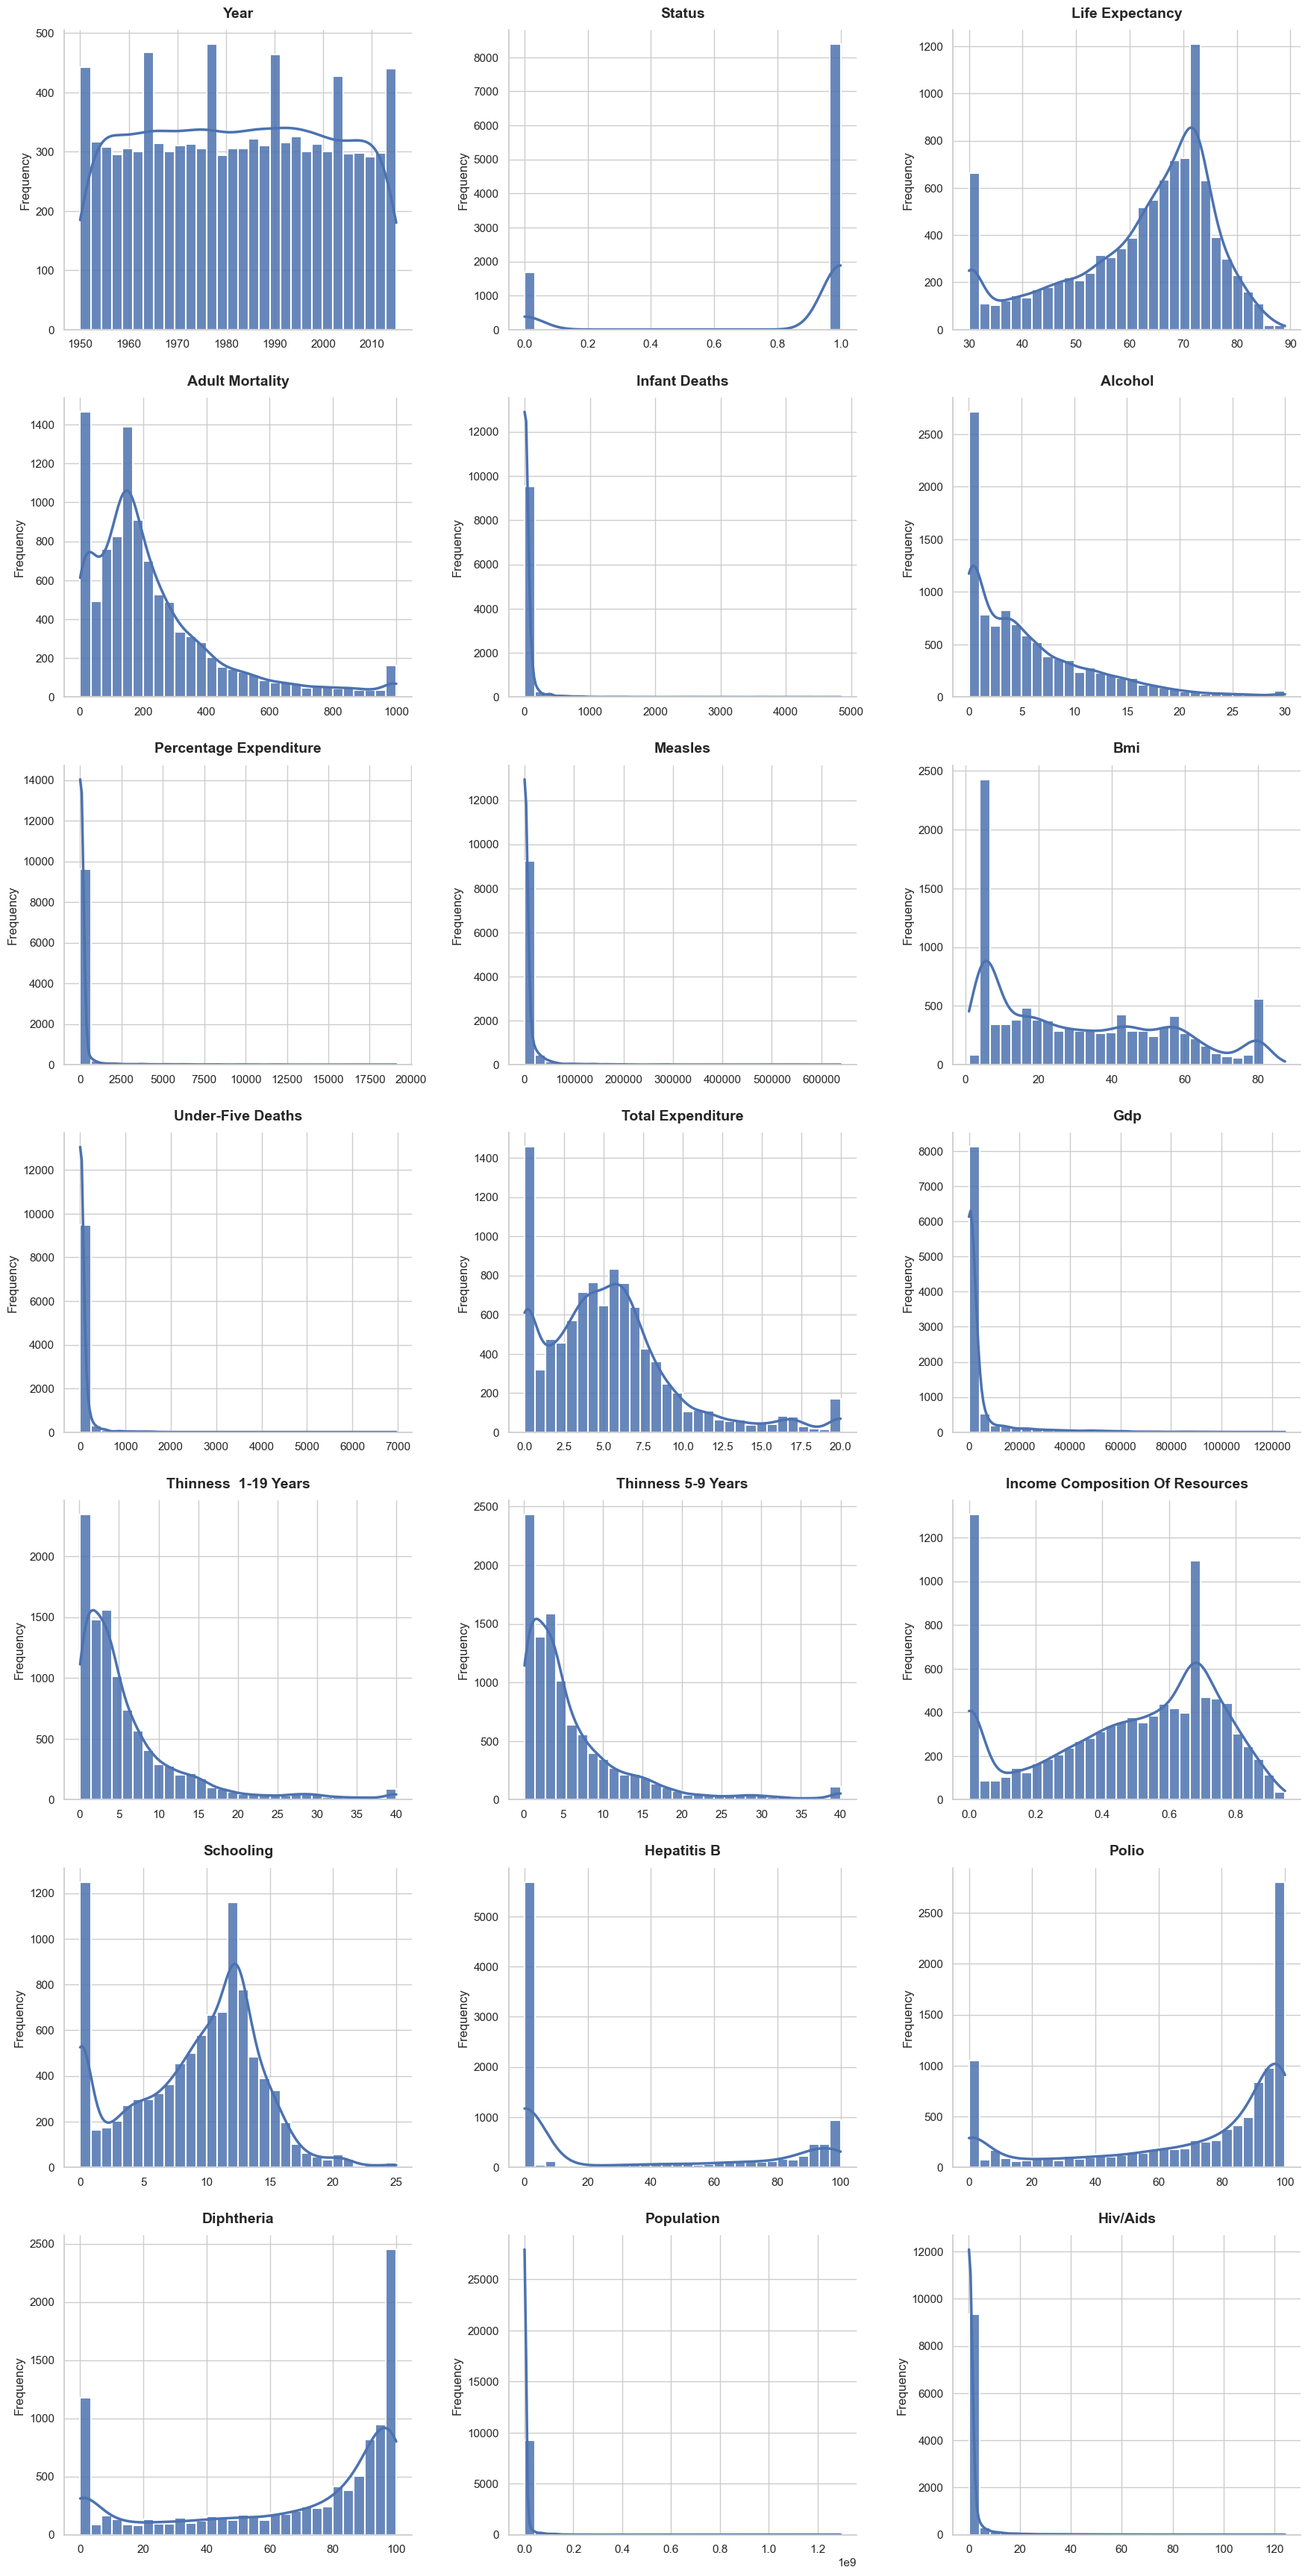

In [ ]:
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

num_cols = df_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

n_num = len(num_cols)
ncols = 3
nrows = (n_num + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        x=df_train[col],
        kde=True,
        bins=30,
        color='#4C72B0',
        edgecolor='white',
        linewidth=1.5,
        alpha=0.85,
        ax=axes[i],
        line_kws={'linewidth': 2.5}
    )
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency', fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=2.0)
plt.show()

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

summary_data = []

def add_summary(col):
    desc = df_train[col].describe()
    summary_data.append({
        'Feature': col,
        'Count': int(desc.get('count', 0)),
        'Null Values': df_train[col].isna().sum(),
        'Mean': desc.get('mean', 0),
        'Std': desc.get('std', 0),
        'Min': desc.get('min', 0),
        '25%': desc.get('25%', 0),
        '50%': desc.get('50%', 0),
        '75%': desc.get('75%', 0),
        'Max': desc.get('max', None),
    })

col_per_1000 = ['Adult Mortality', 'infant deaths', 'under-five deaths', 'HIV/AIDS', 'Measles']
for col in col_per_1000:
    df_train.loc[df_train[col] > 1000, col] = np.nan
    df_train.loc[df_train[col] < 0, col] = np.nan
    add_summary(col)

col_per_100 = ['Hepatitis B', 'Polio', 'Diphtheria', 'thinness 5-9 years', 'thinness  1-19 years', 'percentage expenditure', 'Total expenditure']
for col in col_per_100:
    df_train.loc[df_train[col] > 100, col] = np.nan
    df_train.loc[df_train[col] < 0, col] = np.nan
    add_summary(col)

add_summary('BMI')
add_summary('Schooling')
add_summary('Income composition of resources')
add_summary('Alcohol')
add_summary('GDP')
add_summary('Population')

summary_table = pd.DataFrame(summary_data)
display(summary_table)

pd.reset_option('display.float_format')

,Feature,Count,Null Values,Mean,Std,Min,25%,50%,75%,Max
0,Adult Mortality,10062,8,232.45,213.87,1.00,93.08,171.28,300.02,"1,000.00"
1,infant deaths,9998,72,33.82,90.57,0.00,0.00,4.00,28.00,"1,000.00"
2,under-five deaths,9939,131,44.05,103.59,0.00,0.00,5.00,39.00,970.00
3,HIV/AIDS,10070,0,1.71,7.54,0.10,0.10,0.10,0.27,124.08
4,Measles,6957,3113,86.55,192.68,0.00,0.00,0.00,50.00,999.00
5,Hepatitis B,9614,456,31.15,41.10,0.00,0.00,0.00,80.00,100.00
6,Polio,10057,13,70.76,34.11,0.00,53.00,87.00,97.00,100.00
7,Diphtheria,10057,13,67.34,35.32,0.00,42.00,84.00,96.00,100.00
8,thinness 5-9 years,10047,23,6.13,7.17,0.10,1.50,3.73,7.81,40.00
9,thinness 1-19 years,10047,23,6.13,7.17,0.10,1.60,3.78,7.66,40.00


### EDA

In [ ]:
df_train.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Hepatitis B,Polio,Diphtheria,Population,HIV/AIDS
0,1967,0,75.958705,30.409030,7.0,16.891705,100.000000,NaN,7.022069,10.0,20.000000,79835.055962,0.633306,0.530616,0.747018,12.774990,0.0,76.0,92.0,64121.0,0.100000
1,1990,1,42.915277,101.499444,18.0,8.230195,0.000000,NaN,5.000000,28.0,3.613611,10.000000,11.396052,11.049630,0.300171,9.982904,100.0,53.0,35.0,2364183.0,4.976989
2,1974,1,49.322096,209.702245,81.0,0.010000,0.000000,0.0,30.193667,108.0,6.405683,1766.947595,4.906007,4.736414,0.440699,7.317002,0.0,100.0,100.0,821554.0,0.100000
3,1970,1,30.000000,452.548059,168.0,5.347899,0.000000,NaN,10.879758,298.0,0.000000,1766.947595,11.346782,11.946921,0.677000,12.300000,0.0,83.0,63.0,738541.0,0.100000
4,2010,1,61.800000,261.000000,162.0,1.340000,67.733744,NaN,15.600000,243.0,6.860000,341.399920,11.000000,1.700000,0.401000,8.100000,62.0,69.0,61.0,877267.0,1.700000


#### Arya

Apakah ada negara yang memiliki `GDP` rendah, namun harapan hidup yang tinggi?

In [ ]:
from sklearn.impute import SimpleImputer

df_eda1 = df_train.copy()

# Ganti data placeholder GDP yaitu 10.00 dengan NaN agar tertangkap oleh imputer
# Diidentifikasi di TP 1
df_eda1['GDP'] = df_eda1['GDP'].replace(10.00, np.nan)

columns = df_eda1.columns

# Isi NA
imputer = SimpleImputer(strategy='median')
df_eda1 = imputer.fit_transform(df_eda1)

# Imputer mengeluarkan array NumPy
# Terjemahkan kembali menjadi DF dengan kolom awal
df_eda1 = pd.DataFrame(df_eda1, columns=columns)

# Definisikan 'GDP rendah' dan 'harapan hidup tinggi'
# Definisi awal: GDP bottom 25% (kuartil 1), life expectancy top 25% (kuartil 4)
low_gdp = df_eda1['GDP'].quantile(0.25)
high_le = df_eda1['Life expectancy'].quantile(0.75)

df_filtered = df_eda1[(df_eda1['GDP'] <= low_gdp) & (df_eda1['Life expectancy'] >= high_le)]

df_filtered.describe()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Hepatitis B,Polio,Diphtheria,Population,HIV/AIDS
count,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1266.000000,1.266000e+03,1266.000000
mean,1988.580569,0.763033,74.818207,137.372255,6.304107,5.778893,18.114040,48.050553,41.953476,7.624803,5.501590,1429.369005,2.858402,2.846599,0.638929,12.235383,48.698262,87.007899,86.118483,3.010167e+06,0.190772
std,17.992802,0.425390,3.081810,67.753339,27.168482,5.267921,34.012817,139.898486,23.630369,32.450885,2.882091,566.752070,2.825597,2.923023,0.191037,2.959890,45.032099,21.330487,19.964400,1.036881e+07,0.253483
min,1950.000000,0.000000,72.100000,1.000000,0.000000,0.010000,0.000000,0.000000,1.000000,0.000000,0.000000,12.277330,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,3.600000e+01,0.100000
25%,1975.000000,1.000000,72.201238,104.796093,0.000000,0.195000,0.000000,0.000000,22.105805,0.000000,4.111906,1230.652693,0.900000,0.890552,0.612586,10.801649,0.000000,87.000000,83.000000,5.102830e+05,0.100000
50%,1992.000000,1.000000,73.700000,144.000000,0.000000,4.760000,0.000000,0.000000,44.553620,0.000000,5.580000,1766.947595,2.362424,2.337361,0.677000,12.300000,62.000000,95.000000,94.000000,8.214180e+05,0.100000
75%,2003.000000,1.000000,76.394647,155.088169,3.000000,9.599560,15.606596,2.750000,58.400000,4.000000,7.097340,1766.947595,3.700000,3.600000,0.742284,13.400000,95.000000,99.000000,99.000000,1.285979e+06,0.100000
max,2015.000000,1.000000,89.000000,404.156654,457.000000,29.495500,100.000000,982.000000,80.000000,558.000000,20.000000,1766.947595,18.700000,19.200000,0.945000,21.729106,100.000000,100.000000,100.000000,1.869174e+08,2.728261


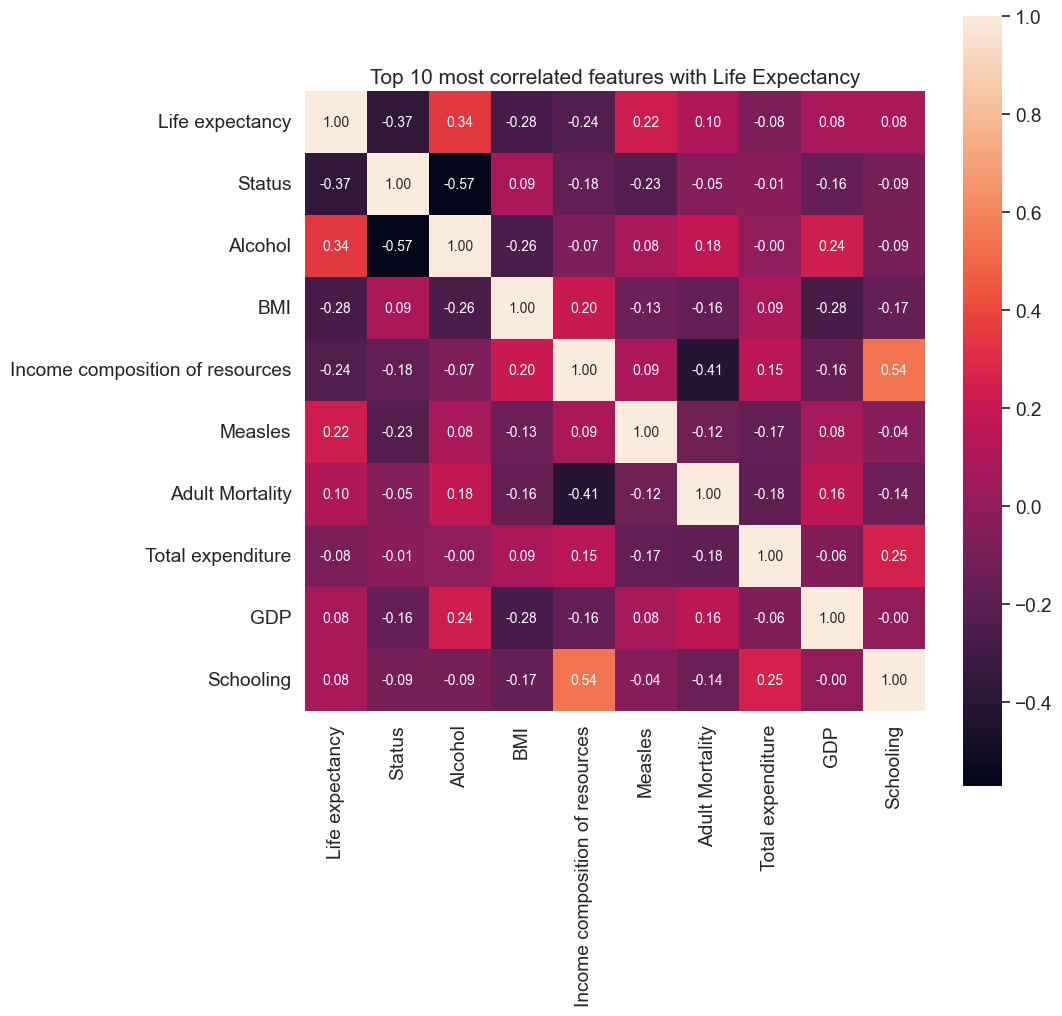

In [ ]:
# Tentukan dan tampilkan fitur-fitur yang paling berkorelasi dengan Life expectancy
# Gunakan Correlations Heatmap

# Get columns
k = 10
corr =  df_filtered.corr()
cols = corr['Life expectancy'].abs().nlargest(k).index
# Set up heatmap
cm = np.corrcoef(df_filtered[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize=(10, 10))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.title('Top 10 most correlated features with Life Expectancy')
plt.show()

##### Interpretasi

Dengan hanya melihat antara data yang memenuhi kriteria (GDP bottom 25% dan life expectancy top 25%), kita dapat mengamati beberapa fitur yang berkorelasi cukup signifikan dengan life expectancy:
  - Status (-0.37, korelasi negatif tingkat rendah-sedang), menunjukkan bahwa ketika nilai Status naik, nilai Life expectancy cenderung turun. Ingat bahwa kita melakukan *encoding* Status, yaitu negara maju (Developed) = 0 dan negara berkembang (Developing) = 1. Artinya, korelasi tersebut sama saja dengan mengatakan bahwa Life expectancy negara berkembang cenderung lebih rendah daripada negara maju.
  - Alcohol (0.34, korelasi positif tingkat rendah-sedang), menunjukkan bahwa ketika konsumsi alkohol meningkat, Life expectancy juga cenderung meningkat. Hal ini mungkin terlihat tidak masuk akal, tetapi ada faktor lain yang mungkin dapat menjelaskan hal ini: pada heatmap, Alcohol berkorelasi negatif kuat dengan Status (-0.57). Artinya, negara maju cenderung memiliki konsumsi alkohol perkapita lebih tinggi daripada negara berkembang.
  - BMI (-0.28, korelasi negatif tingkat rendah), menunjukkan bahwa ketika BMI rata-rata populasi naik, Life expectancy cenderung turun. Melihat dari TP1, BMI merupakan salah satu fitur pada dataset yang terkesan *noisy*. Median BMI di antara data yang memenuhi kriteria adalah 44.56 dan max BMI adalah 80.00, sedangkan BMI 30 sudah dianggap sebagai obesitas menurut WHO. Di sisi lain, minimum BMI yang tercatat adalah 1, sedangkan BMI 18.5 sudah dikategorikan sebagai *underweight*. Oleh karena itu, belum bisa dilakukan penarikan kesimpulan atau penghubungan ke kondisi nyata.

#### Cathlin

Bagaimana korelasi antara konsumsi `alkohol` dan `harapan hidup`, serta hubungannya dengan tingkat `pendapatan`?

In [ ]:
df_eda3 = df_train.copy()

# filter negara dengan low income (quartil 1)
batas_gdp_low = df_eda3['GDP'].quantile(0.25)
df_low_income = df_eda3[df_eda3['GDP'] <= batas_gdp_low]

# hitung pearson corr
correlation = df_low_income['HIV/AIDS'].corr(df_low_income['Life expectancy'])
print(correlation)

-0.19415830931874795


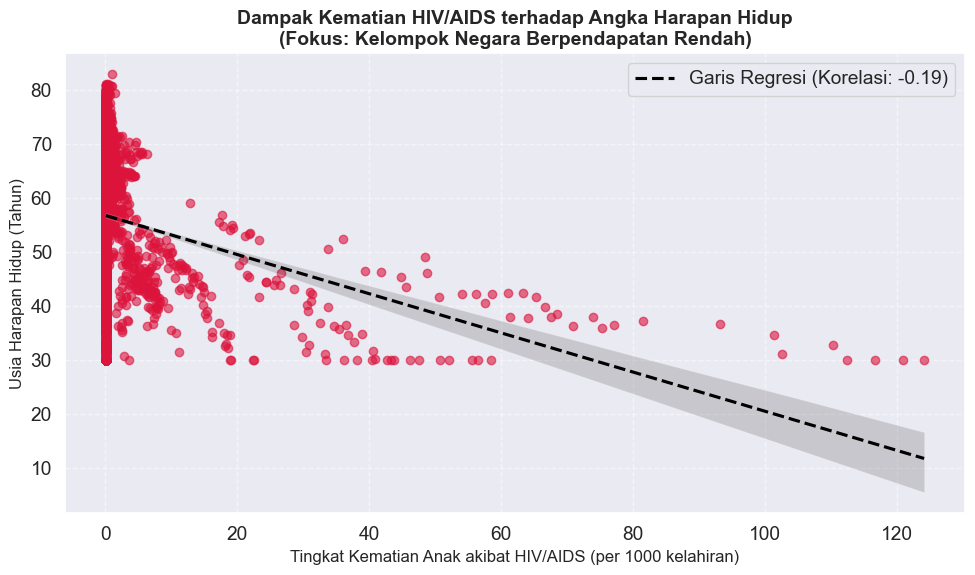

In [ ]:
# buat scatter plot
plt.figure(figsize=(10,6))

sns.regplot(
    data = df_low_income,
    x='HIV/AIDS',
    y = 'Life expectancy',
    scatter_kws={'alpha': 0.6, 'color': 'crimson'},
    line_kws={'color': 'black', 'linestyle': '--', 'label': f'Garis Regresi (Korelasi: {correlation:.2f})'}
)

plt.title('Dampak Kematian HIV/AIDS terhadap Angka Harapan Hidup\n(Fokus: Kelompok Negara Berpendapatan Rendah)', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kematian Anak akibat HIV/AIDS (per 1000 kelahiran)', fontsize=12)
plt.ylabel('Usia Harapan Hidup (Tahun)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### Interpretasi

Berdasarkan hasil scatter plot dan perhitungan pearson correlation, ditemukan adanya koefisien korelasi sebesar -0.19 antara tingkat kematian akibat HIV/AIDS dengan angka Life Expectancy pada kelompok negara berpendapatan rendah (Quartil 1 GDP).

Angka ini menunjukkan adanya korelasi negatif yang lemah. Garis tren melandai ke bawah menunjukan bahwa peningkatan kasus HIV/AIDS tetap berdampak pada Life Expectancy. Tetapi, sebaran data cukup luas id sekitar garis tren yang menunjukan bahwa pada negara berpendapatan rendah, Life Expectancy tidak hanya dipengaruhi oleh suatu penjakit saja.

Faktor eksternal lain, seperti kematian dewasa, nurtisi, dan pemerataan pendidikan kemungkinan besar juga mempengaruhi tinggi rendahnya angka harapan hidup keseluruhan.

#### Aulya

Bagaimana korelasi antara tingkat kematian akibat `HIV/AIDS` dengan `Life Expectancy` pada kelompok negara dengan pendapatan rendah?

Dasar literatur: https://pmc.ncbi.nlm.nih.gov/articles/PMC12358757/#:~:text=Mortality%20and%20life%20expectancy%20are,being%20less%20significant%20in%20women.

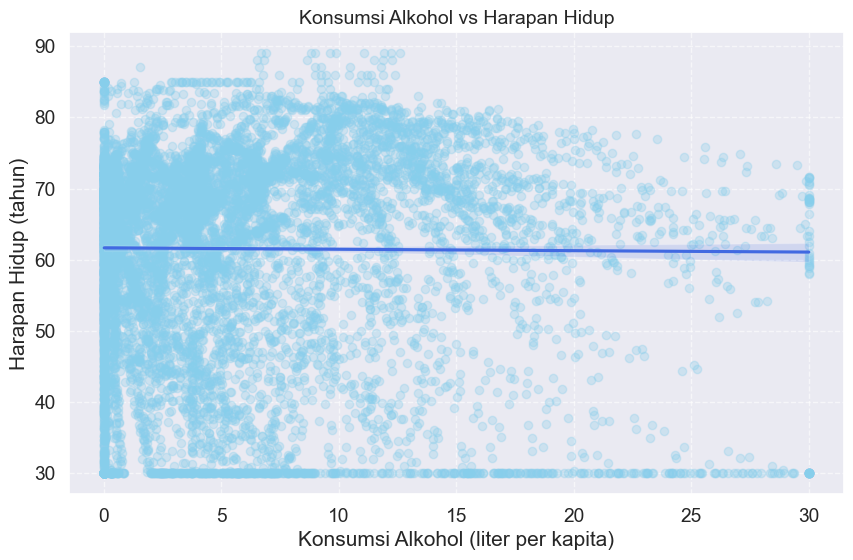

Korelasi Pearson: -0.01


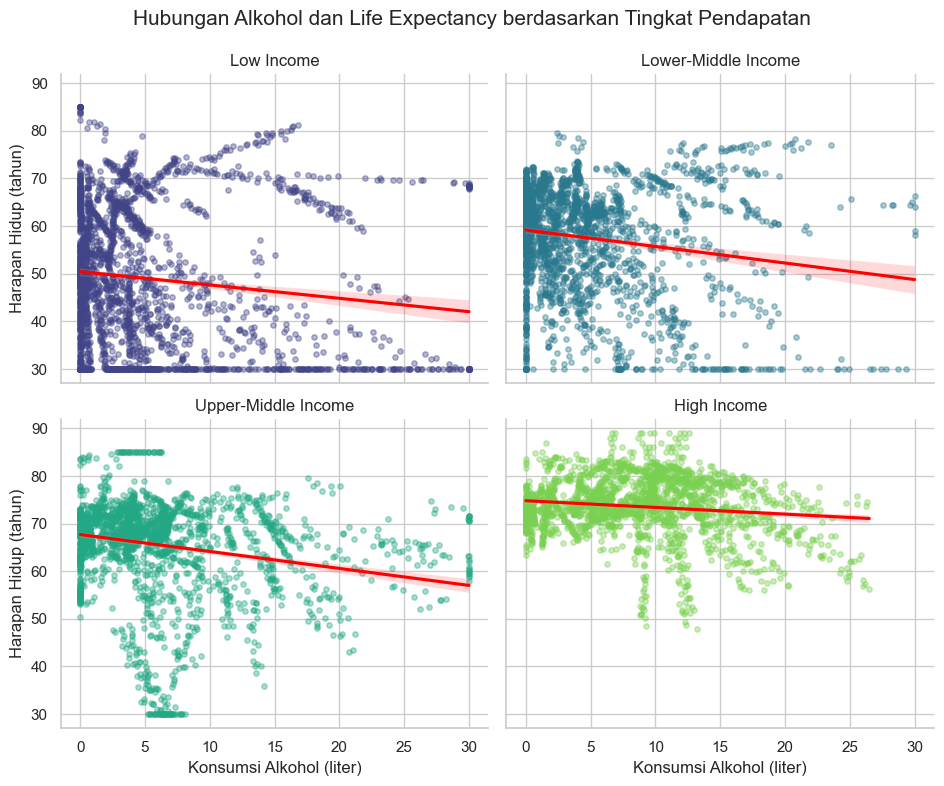

Income_Group                
Low Income           Alcohol   -0.128418
Lower-Middle Income  Alcohol   -0.168208
Upper-Middle Income  Alcohol   -0.218312
High Income          Alcohol   -0.139581
Name: Life expectancy, dtype: float64


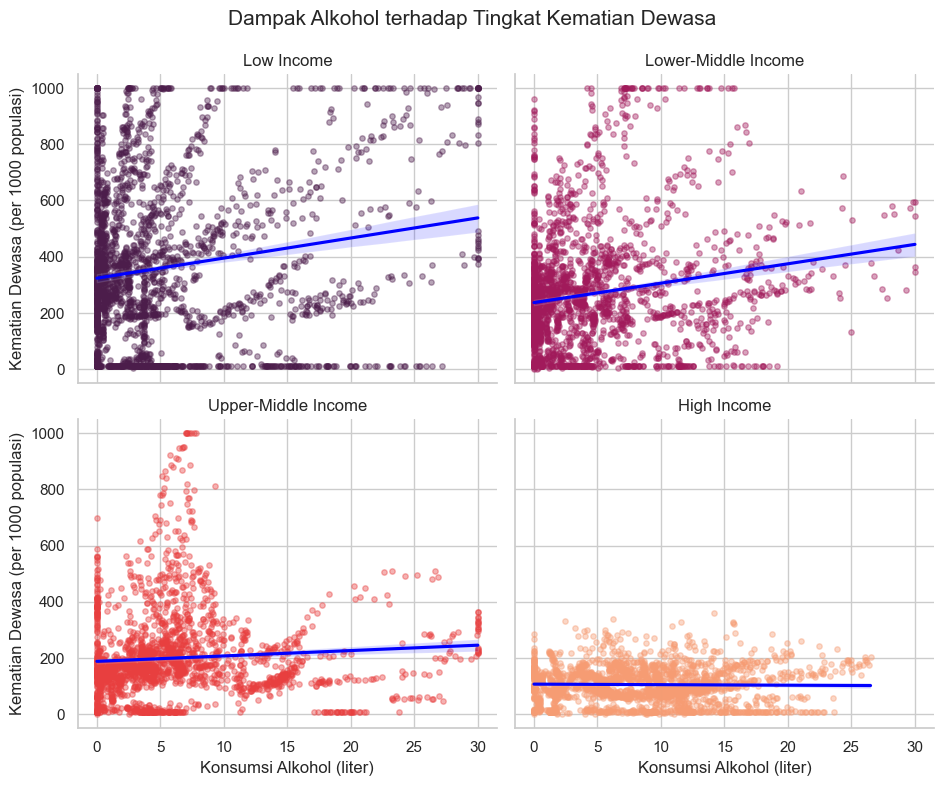


Analisis Korelasi Alkohol dan Adult Mortality
Income_Group                
Low Income           Alcohol    0.170769
Lower-Middle Income  Alcohol    0.174673
Upper-Middle Income  Alcohol    0.078231
High Income          Alcohol   -0.017783
Name: Adult Mortality, dtype: float64


In [ ]:
df_eda2 = df_train.copy()

# ---- melihat hubungan alkohol dan life expectancy secara global
# Filter kolom untuk melihat hubungan alkohol dan life expectancy
df_analysis1 = df_eda2.dropna(subset=['Alcohol', 'Life expectancy'])

# Visualisasi hubungan alkohol dan life expectancy
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analysis1, x='Alcohol', y='Life expectancy',
            scatter_kws={'alpha':0.3, 'color':'skyblue'},
            line_kws={'color':'royalblue'})

plt.title('Konsumsi Alkohol vs Harapan Hidup', fontsize=14)
plt.xlabel('Konsumsi Alkohol (liter per kapita)')
plt.ylabel('Harapan Hidup (tahun)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Lihat angka korelasi
global_corr = df_analysis1['Alcohol'].corr(df_analysis1['Life expectancy'])
print(f"Korelasi Pearson: {global_corr:.2f}")

# ---- melihat hubungan alcohol dan life expectancy berdasarkan level of income
# Filter kolom yang digunakan dan hapus null
used_colls = ['Alcohol', 'Life expectancy', 'Income composition of resources']
df_analysis2 = df_eda2[used_colls].dropna()

# Binning Income Composition of Resources menjadi 4 kategori
df_analysis2['Income_Group'] = pd.qcut(df_analysis2['Income composition of resources'], 4,
                                      labels=['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income'])

# Visualisasi hubungan alkohol, life expectancy, dan level of income
sns.set_theme(style='whitegrid')

visual2 = sns.lmplot(data=df_analysis2, x='Alcohol', y='Life expectancy', col='Income_Group',
                     hue='Income_Group', palette='viridis', col_wrap=2, height=4, aspect=1.2,
                     scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'red'})

visual2.set_axis_labels('Konsumsi Alkohol (liter)', 'Harapan Hidup (tahun)')
visual2. set_titles('{col_name}')
plt.subplots_adjust(top=0.9)
visual2.fig.suptitle('Hubungan Alkohol dan Life Expectancy berdasarkan Tingkat Pendapatan', fontsize=15)

plt.show()
print(df_analysis2.groupby('Income_Group')[['Alcohol', 'Life expectancy']].corr().iloc[0::2, -1])

# ---- hubungan alkohol dan adult morality
# Filter kolom untuk melihat hanya hubungan alkohol dan adult mortality
used_colls3 = ['Alcohol', 'Adult Mortality', 'Income composition of resources']
df_analysis3 = df_eda2[used_colls3].dropna()

# Binning Income
df_analysis3['Income_Group'] = pd.qcut(df_analysis3['Income composition of resources'], 4,
                                       labels=['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income'])

# Visualisasi
sns.set_theme(style='whitegrid')

visual3 = sns.lmplot(data=df_analysis3, x='Alcohol', y='Adult Mortality', col='Income_Group',
                     hue='Income_Group', palette='rocket', col_wrap=2, height=4, aspect=1.2,
                     scatter_kws={'alpha':0.4, 's':15}, line_kws={'color':'blue'})

visual3.set_axis_labels('Konsumsi Alkohol (liter)', 'Kematian Dewasa (per 1000 populasi)')
visual3.set_titles('{col_name}')
plt.subplots_adjust(top=0.9)
visual3.fig.suptitle('Dampak Alkohol terhadap Tingkat Kematian Dewasa', fontsize=15)

plt.show()
print("\nAnalisis Korelasi Alkohol dan Adult Mortality")
print(df_analysis3.groupby('Income_Group')[['Alcohol', 'Adult Mortality']].corr().iloc[0::2, -1])

##### Interpretasi

- Dari sumber literatur, terdapat teori dose-response di mana individu dengan pendapatan rendah menghadapi risiko kesehatan yang lebih besar meskipun jumlah konsumsi alkoholnya sama dengan individu dengan pendapatan tinggi. Hal ini menjadi alasan mengapa di grafik pertama, hubungan konsumsi alkohol dan life expectancy secara global tidak terlalu terlihat dan hanya memiliki nilai korelasi pearson -0.01. Hubungan keduanya tidak bisa ditarik secara eksplisit karena bisa jadi ada faktor lain seperti akses terhadap fasilitas medis atau kualitas nutrisi, yang ikut memengaruhi tingkat harapan hidup.

- Kemudian, dilakukan segmentasi sesuai tingkat pendapatan (low, lower-middle, upper-middle, dan high) dengan binning pada Income composition of resources untuk melihat seberapa berpengaruh alkohol jika dilihat dari kelompok dengan ekonomi rendah dibandingkan kelompok ekonomi tinggi. Hasilnya, nilai korelasi berubah dan membuktikan bahwa alkohol sebenarnya memiliki pengaruh negatif yang baru bisa terbaca setelah menghilangkan bias pendapatan. Hal ini mengonfirmasi terjadinya Simpson's Paradox di mana hubungan negatif yang konsisten di tiap kelompok pendapatan tersembunyi saat data dianalisis secara global. Angka korelasi yang berkisar antara -0.128 hingga -0.218 membuktikan bahwa ketika membandingkan negara dengan kapasitas ekonomi yang setara, peningkatan konsumsi alkohol konsisten diikuti dengan penurunan angka harapan hidup.

- Terakhir, analisis lanjutan dilakukan dengan menggunakan Adult Mortality untuk mengeliminasi noise akibat data infant deaths yang tidak relevan dengan konsumsi alkohol. Hasilnya, didapatkan korelasi positif pada kelompok low income, lower-middle income, dan upper-middle income yang mengonfirmasi bahwa angka kematian dewasa cenderung naik seiring dengan kenaikan konsumsi alkohol. Namun, kelompok high income justru mendapatkan angka negatif yang mendekati nol sehingga menandakan tingkat konsumsi alkohol hampir tidak punya hubungan sama sekali dengan kematian dewasa. Hal ini mengindikasikan bahwa di negara high income, ada faktor lain yang bisa meredam tingkat kematian akibat konsumsi alkohol.

Dari hasil analisis yang dilakukan, alkohol terbukti menjadi salah satu faktor signifikan terhadap life expectancy, terutama pada negara dengan tingkat pendapatan rendah dan menengah. Namun, masih ada faktor lain yang bisa diteliti untuk menemukan faktor kunci dalam angka life expectancy.

#### Aydin

Bagaimana pengaruh `pengeluaran kesehatan` terhadap angka `harapan hidup` jika dianalisis berdasarkan skala ekonomi riil (`PDB`) suatu negara?

--- BUKTI JUSTIFIKASI FEATURE ENGINEERING ---
1. Korelasi persentase pengeluaran terhadap life expectancy: 0.2704
2. Korelasi persentase * Pengeluaran Pemerintah terhadap life expectancy: 0.2262
3. Korelasi persentase * GDP per kapita terhadap life expectancy: 0.2292


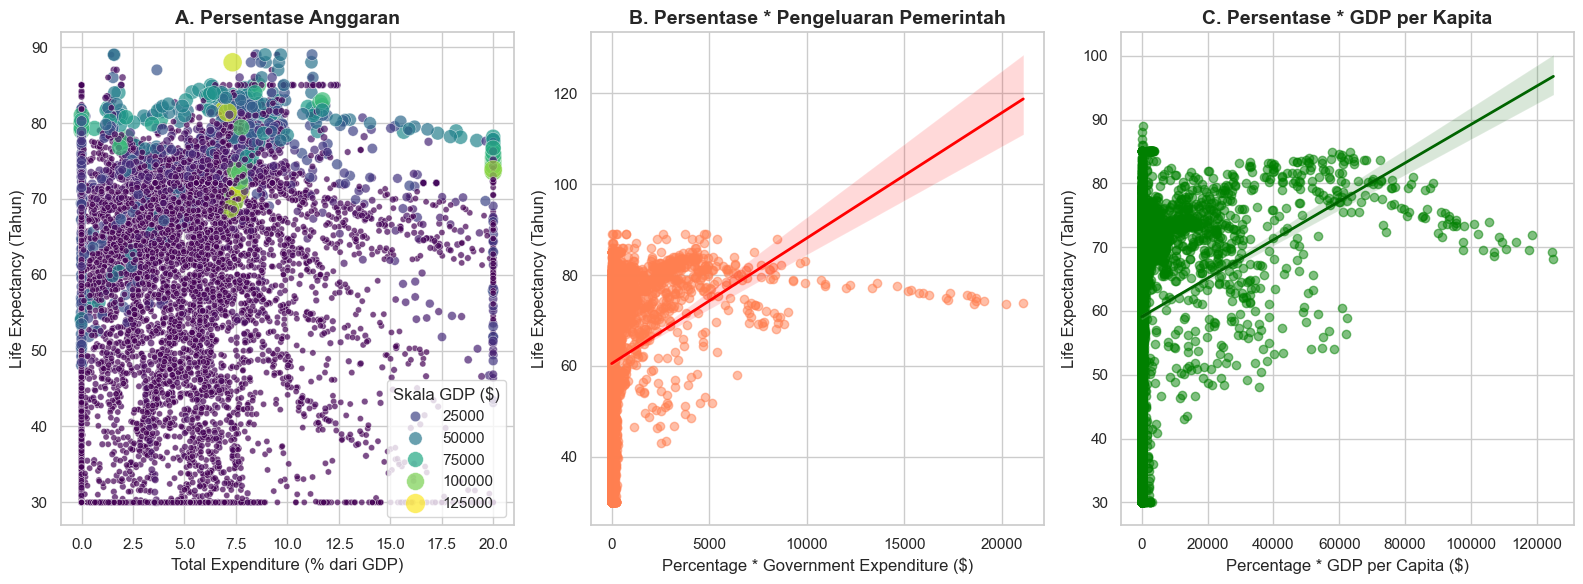

In [ ]:
df_eda4 = df_train.copy()

# 2. FEATURE ENGINEERING (Target: Uang Riil)
df_eda4['health_expenditure_respect_to_gov_spend'] = (df_eda4['Total expenditure'] / 100) * (df_eda4['GDP'])
df_eda4['health_expenditure_respect_to_gdp'] = (df_eda4['percentage expenditure'] / 100) * (df_eda4['GDP'])

corr_percentage = df_eda4['percentage expenditure'].corr(df_eda4['Life expectancy'])
corr_gov_spend = df_eda4['health_expenditure_respect_to_gov_spend'].corr(df_eda4['Life expectancy'])
corr_gdp = df_eda4['health_expenditure_respect_to_gdp'].corr(df_eda4['Life expectancy'])

print("--- BUKTI JUSTIFIKASI FEATURE ENGINEERING ---")
print(f"1. Korelasi persentase pengeluaran terhadap life expectancy: {corr_percentage:.4f}")
print(f"2. Korelasi persentase * Pengeluaran Pemerintah terhadap life expectancy: {corr_gov_spend:.4f}")
print(f"3. Korelasi persentase * GDP per kapita terhadap life expectancy: {corr_gdp:.4f}")

# 4. VISUALISASI PERBANDINGAN
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Plot A: Persentase
scatter = sns.scatterplot(
    data=df_eda4, x='Total expenditure', y='Life expectancy',
    hue='GDP', palette='viridis', size='GDP', sizes=(20, 200), alpha=0.7, ax=axes[0]
)
# Menambahkan nilai korelasi ke judul
axes[0].set_title(f'A. Persentase Anggaran', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Expenditure (% dari GDP)')
axes[0].set_ylabel('Life Expectancy (Tahun)')
axes[0].legend(title='Skala GDP ($)', loc='lower right')

# Plot B: Persentase terhadap Gov Spend
sns.regplot(
    x=df_eda4['health_expenditure_respect_to_gov_spend'],
    y=df_eda4['Life expectancy'],
    scatter_kws={'alpha': 0.5, 'color': 'coral'},
    line_kws={'color': 'red', 'linewidth': 2}, ax=axes[1]
)
axes[1].set_title(f'B. Persentase * Pengeluaran Pemerintah', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Percentage * Government Expenditure ($)')
axes[1].set_ylabel('Life Expectancy (Tahun)')

# Plot C: Persentase terhadap GDP/kapita
sns.regplot(
    x=df_eda4['health_expenditure_respect_to_gdp'],
    y=df_eda4['Life expectancy'],
    scatter_kws={'alpha': 0.5, 'color': 'green'},
    line_kws={'color': 'darkgreen', 'linewidth': 2}, ax=axes[2]
)
axes[2].set_title(f'C. Persentase * GDP per Kapita', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Percentage * GDP per Capita ($)')
axes[2].set_ylabel('Life Expectancy (Tahun)')



plt.tight_layout()
plt.show()

##### Interpretasi
Berdasarkan hasil korelasi, fitur asli `percentage expenditure` secara tak terduga menunjukkan kekuatan prediktif tertinggi (0.2704) dibandingkan fitur turunan pengeluaran absolutnya (0.2262 dan 0.2292), yang secara empiris mengindikasikan bahwa proses *feature engineering* matematis pada kasus ini justru mendegradasi kualitas data. Penurunan korelasi ini sangat logis terjadi akibat efek amplifikasi *noise* (ketidakpastian imputasi); ketika kolom-kolom dasar yang memiliki banyak *missing value* diisi menggunakan estimasi proksi dari *KNN Imputer*, mengalikan dua kolom hasil estimasi tersebut (misalnya persentase dikali GDP) akan melipatgandakan margin error komputasi dan merusak tren aslinya terhadap target *Life expectancy*. Oleh karena itu, sebagai langkah pemodelan yang paling *robust*, kita harus membatalkan transformasi finansial ke nilai absolut dan cukup menggunakan fitur `percentage expenditure` dalam bentuk aslinya, karena nilai tersebut terbukti paling murni dan kebal terhadap bias amplifikasi data yang diimputasi.

---

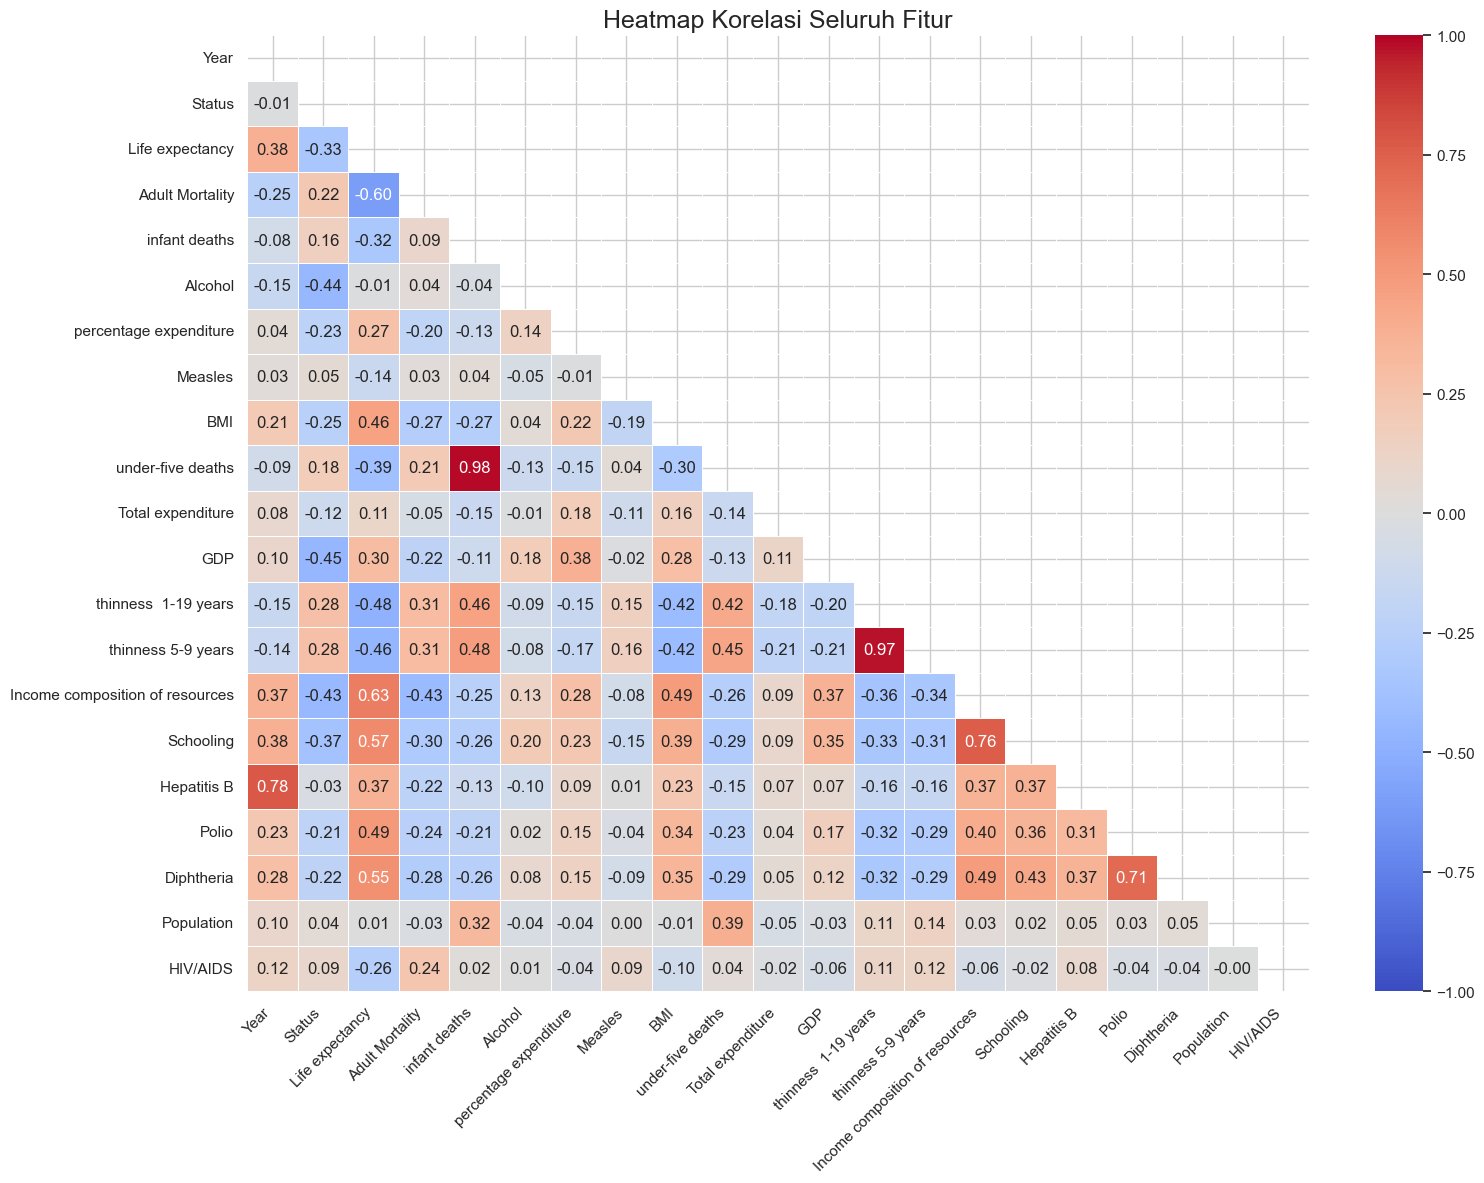

In [ ]:
numeric_df = df_train.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Seluruh Fitur', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
def clean(df):
    # 1. thinness 5-9 years dan thinness  1-19 years memiliki korelasi sangat tinggi
    df.drop(columns=['thinness 5-9 years'], inplace=True)

    # 2. under five deaths dan infant deaths memiliki korelasi sangat tinggi
    df.drop(columns=['infant deaths'], inplace=True)

    # 3. Polio dan Diphtheria memiliki korelasi tinggi
    df.drop(columns=['Diphtheria'], inplace=True)

    # 4. percentage expenditure banyak null value (>50%)
    df.drop(columns=['percentage expenditure'], inplace=True)

    # 5. Income composition of resources merupakan fitur turunan
    df.drop(columns=['Income composition of resources'], inplace=True)

    # 6. Year tidak relevan
    df.drop(columns=['Year'], inplace=True)


clean(df_train)
clean(df_test)

 Jumlah Missing Values  Jumlah Row  Persentase (%)
                     0        6089           60.47
                     1        3261           32.38
                     2         479            4.76
                     3         126            1.25
                     4          67            0.67
                     5          31            0.31
                     6          11            0.11
                     7           6            0.06


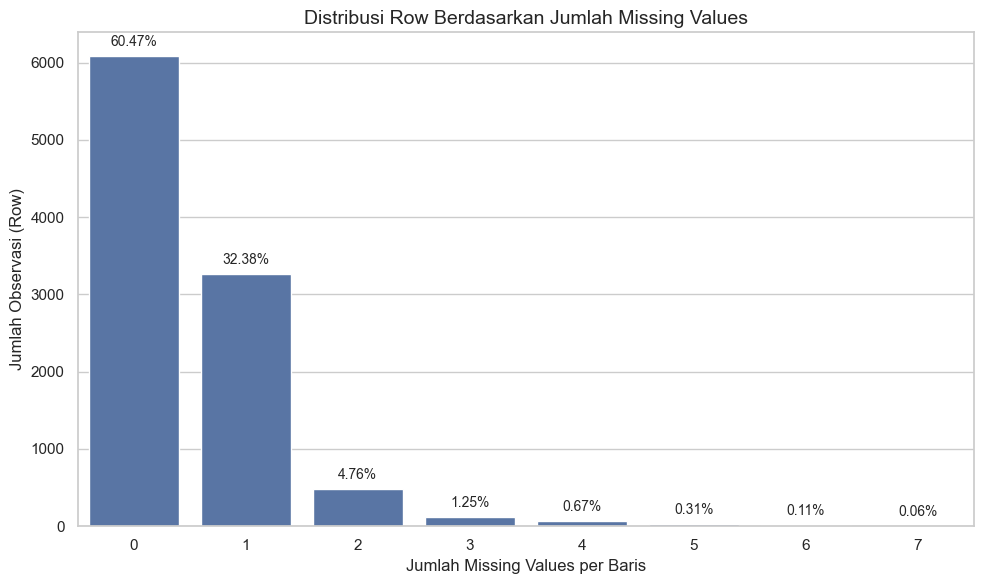

In [ ]:
missing_counts = df_train.isnull().sum(axis=1)

dist = missing_counts.value_counts().sort_index()
dist_pct = (missing_counts.value_counts(normalize=True).sort_index() * 100).round(2)

missing_summary_df = pd.DataFrame({
    'Jumlah Missing Values': dist.index,
    'Jumlah Row': dist.values,
    'Persentase (%)': dist_pct.values
})

print(missing_summary_df.to_string(index=False))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=missing_summary_df, x='Jumlah Missing Values', y='Jumlah Row')

for p, pct in zip(ax.patches, missing_summary_df['Persentase (%)']):
    ax.annotate(f"{pct}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5),
                textcoords='offset points')

plt.title('Distribusi Row Berdasarkan Jumlah Missing Values', fontsize=14)
plt.xlabel('Jumlah Missing Values per Baris', fontsize=12)
plt.ylabel('Jumlah Observasi (Row)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df_train[missing_counts < 4].copy()

print(f"Jumlah baris awal: {len(df_train)}")
print(f"Jumlah baris setelah dibersihkan: {len(df_clean)}")
print(f"Total baris yang dihapus (>= 4 missing values): {len(df_train) - len(df_clean)}")

df_train = df_clean.reset_index(drop=True)

Jumlah baris awal: 10070
Jumlah baris setelah dibersihkan: 9955
Total baris yang dihapus (>= 4 missing values): 115


In [ ]:
# Impute dengan KNNImputer

from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)

cols = df_train.columns
df_imputed = imputer.fit_transform(df_train)

# Kembalikan ke bentuk dataframe
df_train = pd.DataFrame(df_imputed, columns=cols)

display(df_train)

X = df_train.drop(columns=['Life expectancy', 'Status'])
y = df_train['Life expectancy']

,Status,Life expectancy,Adult Mortality,Alcohol,Measles,BMI,under-five deaths,Total expenditure,GDP,thinness 1-19 years,Schooling,Hepatitis B,Polio,Population,HIV/AIDS
0,0.0,75.958705,30.409030,16.891705,197.2,7.022069,10.0,20.000000,79835.055962,0.633306,12.774990,0.0,76.0,64121.00,0.100000
1,1.0,42.915277,101.499444,8.230195,273.6,5.000000,28.0,3.613611,10.000000,11.396052,9.982904,100.0,53.0,2364183.00,4.976989
2,1.0,49.322096,209.702245,0.010000,0.0,30.193667,108.0,6.405683,1766.947595,4.906007,7.317002,0.0,100.0,821554.00,0.100000
3,1.0,30.000000,452.548059,5.347899,42.2,10.879758,298.0,0.000000,1766.947595,11.346782,12.300000,0.0,83.0,738541.00,0.100000
4,1.0,61.800000,261.000000,1.340000,276.0,15.600000,243.0,6.860000,341.399920,11.000000,8.100000,62.0,69.0,877267.00,1.700000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9950,1.0,54.000000,496.000000,8.500000,81.0,44.300000,82.0,7.570000,5631.734850,1.600000,12.900000,83.0,79.0,4823384.48,28.100000
9951,0.0,61.091817,93.906388,15.523594,19.0,80.000000,6.0,0.000000,18180.412076,1.309101,14.667046,0.0,100.0,4860065.00,0.100000
9952,1.0,63.257414,14.720870,0.562890,197.2,5.000000,30.0,0.100080,10.000000,6.375319,5.548524,0.0,100.0,10777319.00,0.100000
9953,1.0,55.229174,296.233241,5.632786,219.8,14.602534,23.0,5.879722,1766.947595,0.100000,6.587215,0.0,15.0,1210398.00,0.194655


## Model Fitting

### Arya

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import KFold

In [ ]:
! pip install optuna

In [ ]:
# # # Make the pipeline and tune the hyperparameters
# import optuna
# from sklearn.model_selection import cross_val_score
# from sklearn.model_selection import KFold

# def objective(trial):
#   min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 100)
#   max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 15, 63)
#   max_iter = trial.suggest_int('max_iter', 100, 300)
#   learning_rate = trial.suggest_float('learning_rate', 0.01, 0.25, log=True)
#   l2_regularization = trial.suggest_float('l2_regularization', 0.1, 1.0, log=True)
#   quantile = trial.suggest_float('quantile', 0.1, 0.9, log=True)

#   pipeline = Pipeline([
#       ('imputer', SimpleImputer(strategy='median')),
#       ('scaler', StandardScaler()),
#       ('model', HistGradientBoostingRegressor(min_samples_leaf=min_samples_leaf, max_leaf_nodes=max_leaf_nodes, max_iter=max_iter, learning_rate=learning_rate, l2_regularization=l2_regularization, early_stopping=True, loss='quantile', quantile=quantile))
#   ])

#   cv = KFold(n_splits=5, shuffle=True, random_state=42)
#   score = cross_val_score(pipeline, X, y, cv=cv, scoring='r2').mean()
#   return score

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=200)

# print("Best hyperparameters:", study.best_params)
# print("Best accuracy:", study.best_value)

R2 score: 0.9768814400057136
Mean squared error: 4.649059957893061


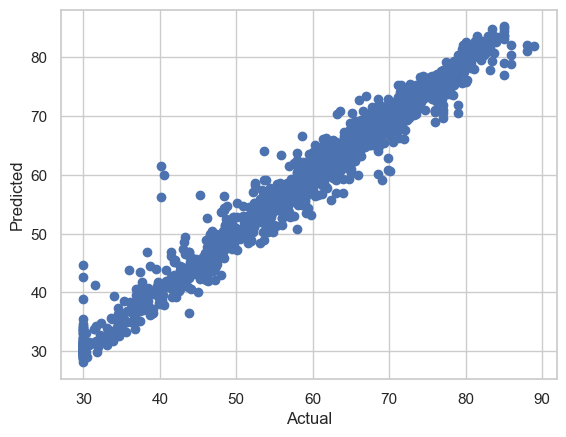

In [ ]:
# Make the final pipeline
# Final parameters: Best hyperparameters: {min_samples_leaf=11, max_leaf_nodes=63, max_iter=293, learning_rate=0.09876768155121413, l2_regularization=0.21412337828377956, early_stopping=True, loss='quantile', quantile=0.4813646342602237}
pipeline = Pipeline([
      ('imputer', SimpleImputer(strategy='median')),
      ('model', HistGradientBoostingRegressor(min_samples_leaf=11, max_leaf_nodes=63, max_iter=293, learning_rate=0.09876768155121413, l2_regularization=0.21412337828377956, early_stopping=True, loss='quantile', quantile=0.4813646342602237))
  ])

# Train the model
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
pipeline.fit(X_train, y_train)

# Predict the validation data: calculate the R2 score
y_pred = pipeline.predict(X_val)
r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
print('R2 score:', r2)
print('Mean squared error:', mse)

plt.scatter(y_val, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [ ]:
# Phase 2: Real prediction

# Train on full data
pipeline.fit(X, y)

# Predict test data
X_test = df_test
res = pipeline.predict(X_test)

res_df = pd.DataFrame(
    {'id': X_test.index,
     'Life Expectancy': res}
)

display(res_df)


,id,Life Expectancy
0,0,72.300629
1,1,73.806772
2,2,56.474057
3,3,33.977851
4,4,57.966694
...,...,...
1254,1254,65.702494
1255,1255,79.037091
1256,1256,69.037928
1257,1257,65.766288


### Cathlin

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3044
[LightGBM] [Info] Number of data points in the train set: 7964, number of used features: 13
[LightGBM] [Info] Start training from score 61.758634
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3047
[LightGBM] [Info] Number of data points in the train set: 7964, number of used features: 13
[LightGBM] [Info] Start training from score 61.730683
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3045
[LightGBM] [Info] Number of data points in the train set: 7964, number of used features: 13
[LightGBM] [Info] Start training from score 61.642464
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001228 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3046
[LightGBM] [Info] Number of data points in the train set: 7964, number of used features: 13
[LightGBM] [Info] Start training from score 61.646852
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3044
[LightGBM] [Info] Number of data points in the train set: 7964, number of used features: 13
[LightGBM] [Info] Start training from score 61.598964
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\kaydo\AppData\Local\Temp\ipykernel_12256\1352453320.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Kepentingan', y='Fitur', palette='magma')


R-squared: 0.98534
RMSE   : 1.72349


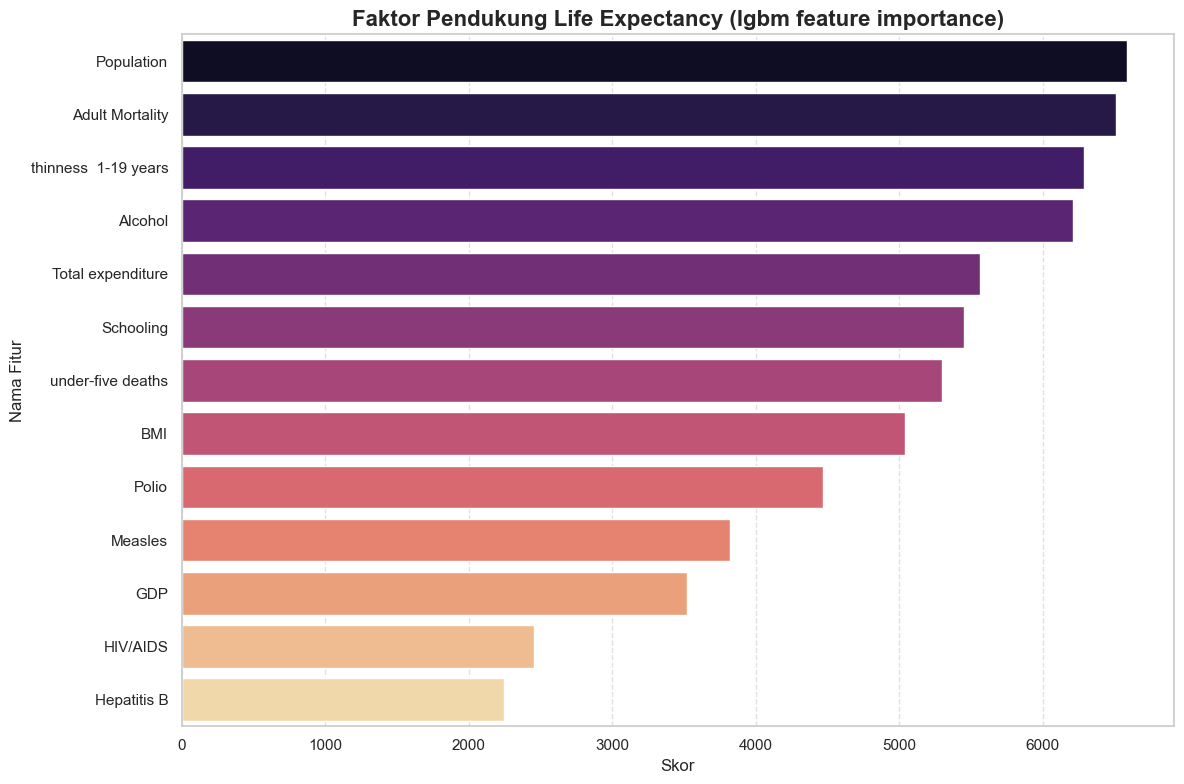

In [ ]:
from lightgbm import LGBMRegressor

# set up lightgbm
lgbm_model = LGBMRegressor(
    n_estimators=1500,     # jumlah pohon
    learning_rate=0.03,    # kecepatan belajar
    max_depth=7,           # kedalaman pohon
    num_leaves=63,         # jumlah daun
    subsample=0.8,         # pakai 80% data per pohon (mencegah overfit)
    colsample_bytree=0.8,  # pakai 80% fitur per pohon
    random_state=42,
    n_jobs=-1
)

# pipeline = Imputer Median -> Standarisasi -> LGBM
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', lgbm_model)
])



# k-fold training dan evaluasi
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X))
test_predictions = np.zeros(len(X_test))

fold = 1
for train_idx, val_idx in kf.split(X):

    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]

    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

    pipeline.fit(X_tr, y_tr)

    # prediksi validasi lokal
    oof_predictions[val_idx] = pipeline.predict(X_va)

    # prediksi soal kaggle
    test_predictions += pipeline.predict(X_test) / N_SPLITS

    fold += 1



# evaluasi dengan skor R2 dan RMSE
r2_oof = r2_score(y, oof_predictions)
rmse_oof = np.sqrt(mean_squared_error(y, oof_predictions))

print(f"R-squared: {r2_oof:.5f}")
print(f"RMSE   : {rmse_oof:.5f}")



# submission
submission_df = pd.DataFrame({
    'id': range(len(test_predictions)),
    'Predicted_Life_Expectancy': test_predictions
})

nama_file = 'submission_lgbm4.csv'
submission_df.to_csv(nama_file, index=False)

 # tarik model lgbm langsung dari dalem pipeline
model_lgbm_asli = pipeline.named_steps['model']

# ambil skor seberapa besar pengaruh fiturnya
skor_kepentingan = model_lgbm_asli.feature_importances_

# ngambil nama-nama kolom dari data kita
nama_fitur = X.columns

# gabungin jadi satu tabel (dataframe) terus diurutin dari yang paling berpengaruh
df_importance = pd.DataFrame({
    'Fitur': nama_fitur,
    'Kepentingan': skor_kepentingan
}).sort_values(by='Kepentingan', ascending=False)

# visualisasi grafik
plt.figure(figsize=(12, 8))
sns.barplot(data=df_importance, x='Kepentingan', y='Fitur', palette='magma')

plt.title('Faktor Pendukung Life Expectancy (lgbm feature importance)', fontsize=16, fontweight='bold')
plt.xlabel('Skor', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

### Aulya

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, VotingRegressor
from sklearn.model_selection import cross_val_score

# Model 1: Random Forest
model_rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Model 2: HistGradientBoosting
model_hgb = HistGradientBoostingRegressor(
    max_iter=5000,
    learning_rate=0.01,
    max_depth=12,
    l2_regularization=0.1,
    random_state=42
)

# Menggabungkan 2 model dalam VotingRegressor untuk mengambil rata-rata prediksi
voting_model = VotingRegressor(estimators=[
    ('rf', model_rf),
    ('hgb', model_hgb)
])

# Masukkan ke dalam Pipeline
pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('model', voting_model)
])

# K-Fold Cross Validation
print("Cross-Validation R2 Score")
scores = cross_val_score(pipeline_final, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f"Mean R2 (5-Fold CV): {scores.mean():.4f}")
print("\n")

# Train Model Final
pipeline_final.fit(X, y)

# Menyamakan kolom data test dengan data train
X_test = df_test
preds = pipeline_final.predict(X_test)

res_df = pd.DataFrame({
    'Life Expectancy': preds
})
res_df.index.name = 'id'

print("Prediksi data test")
display(res_df)

Cross-Validation R2 Score
Mean R2 (5-Fold CV): 0.9863


Prediksi data test


,Life Expectancy
id,
0,72.979151
1,72.593039
2,56.305985
3,35.551037
4,57.428948
...,...
1254,65.883267
1255,79.829356
1256,67.867617


### Aydin

In [ ]:
from sklearn.svm import SVR
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline


# ==============================================================================
# 1. PERSIAPAN DATA TRAIN & TEST
# ==============================================================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=67)

# ==============================================================================
# 2. MEMBANGUN ARSITEKTUR PIPELINE SVR
# ==============================================================================
base_svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

model_with_target_transform = TransformedTargetRegressor(
    regressor=base_svr_pipeline,
    transformer=PowerTransformer(method='yeo-johnson')
)

param_dist = {
    'regressor__model__C': [1, 10, 50, 100, 150, 200],
    'regressor__model__gamma': ['scale', 'auto', 0.01, 0.05, 0.1],
    'regressor__model__kernel': ['rbf']
}

print("Memulai proses training & tuning SVR dengan 5-Fold CV...")
search_svr = RandomizedSearchCV(
    model_with_target_transform,
    param_distributions=param_dist,
    n_iter=25,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search_svr.fit(X_train, y_train)

# ==============================================================================
# 3. EVALUASI MODEL
# ==============================================================================
best_svr = search_svr.best_estimator_
y_pred_val = best_svr.predict(X_val)

r2_val = r2_score(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))

print("\n--- HASIL EVALUASI MODEL SVR AYDIN (FINAL) ---")
print(f"Hyperparameter Terbaik : {search_svr.best_params_}")
print(f"R-squared (R2) Score   : {r2_val:.4f}")
print(f"RMSE                   : {rmse_val:.4f}")

# ==============================================================================
# 5. PREDIKSI UNTUK KAGGLE SUBMISSION
# ==============================================================================
cols = df_test.columns
df_imputed = imputer.fit_transform(df_test)
df_test = pd.DataFrame(df_imputed, columns=cols)

final_predictions = best_svr.predict(df_test)

submission_df = pd.DataFrame({
    'id': df_test['id'] if 'id' in df_test.columns else range(len(final_predictions)),
    'Predicted_Life_Expectancy': final_predictions
})

display(submission_df)

Memulai proses training & tuning SVR dengan 5-Fold CV...


c:\Users\kaydo\Documents\study\Kasdad\env\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan        nan        nan 0.96600835
        nan        nan        nan        nan        nan        nan
 0.95974953 0.95770346        nan        nan        nan 0.77764367
        nan 0.8867014         nan        nan 0.96051348        nan
        nan]
  warnings.warn(



--- HASIL EVALUASI MODEL SVR AYDIN (FINAL) ---
Hyperparameter Terbaik : {'regressor__model__kernel': 'rbf', 'regressor__model__gamma': 0.1, 'regressor__model__C': 10}
R-squared (R2) Score   : 0.9698
RMSE                   : 2.5262


,id,Predicted_Life_Expectancy
0,0,57.208982
1,1,69.769159
2,2,55.202041
3,3,37.244978
4,4,59.379264
...,...,...
1254,1254,63.629188
1255,1255,80.148482
1256,1256,67.736427
1257,1257,66.578006
